<a href="https://colab.research.google.com/github/ekttd/student-productivity/blob/main/student_productivity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import pandas as pd
import math

from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.ticker import FormatStrFormatter

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sehaj1104/student-productivity-and-digital-distraction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-productivity-and-digital-distraction-dataset' dataset.
Path to dataset files: /kaggle/input/student-productivity-and-digital-distraction-dataset


In [9]:
df = pd.read_csv('/kaggle/input/student-productivity-and-digital-distraction-dataset/student_productivity_distraction_dataset_20000.csv')
df.head()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  object 
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  fo

# Анализ выбросов


---
Лучший способ исследовать выбросы box plot и гистограммы.

Атрибуты, на которых исследуем выбросы:
> пока исследования по всем атрибутам, потом возможно исключение несущечтвенных




In [52]:
# только числовые признаки
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# исключение идентификатора
if 'student_id' in numeric_cols:
    numeric_cols.remove('student_id')

print(numeric_cols)

['age', 'study_hours_per_day', 'sleep_hours', 'phone_usage_hours', 'social_media_hours', 'youtube_hours', 'gaming_hours', 'breaks_per_day', 'coffee_intake_mg', 'exercise_minutes', 'assignments_completed', 'attendance_percentage', 'stress_level', 'focus_score', 'final_grade', 'productivity_score']


In [17]:
def hist_for_atribute_set(df, labels, ax, bin_num=25, df2=pd.DataFrame(),
                          ylim=None, ylabel=None, y_scale='linear'):

  for i, col in enumerate(labels):
    ax[i].set_yscale(y_scale)
    ax[i].tick_params(labelsize=10)
    ax[i].set_xlabel(col)

    # уберем лишние границы графика
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['top'].set_visible(False)
    ax[i].grid()

    ax[i].hist(df[col], bin_num, density=False, color='#377eb8', alpha=.75) # синий
    if (not df2.empty):
      ax[i].hist(df2[col], bin_num, density=False, color='#e41a1c', alpha=.45) # красный '#e41a1c'

  # если графиков меньше чем есть в сетке, убираем лишние оси
  len_labels = len(labels)
  len_ax = len(ax)
  if len_labels < len_ax:
    for ax in ax[len_labels : len_labels + (len_ax - len_labels)]:
      ax.axis('off')

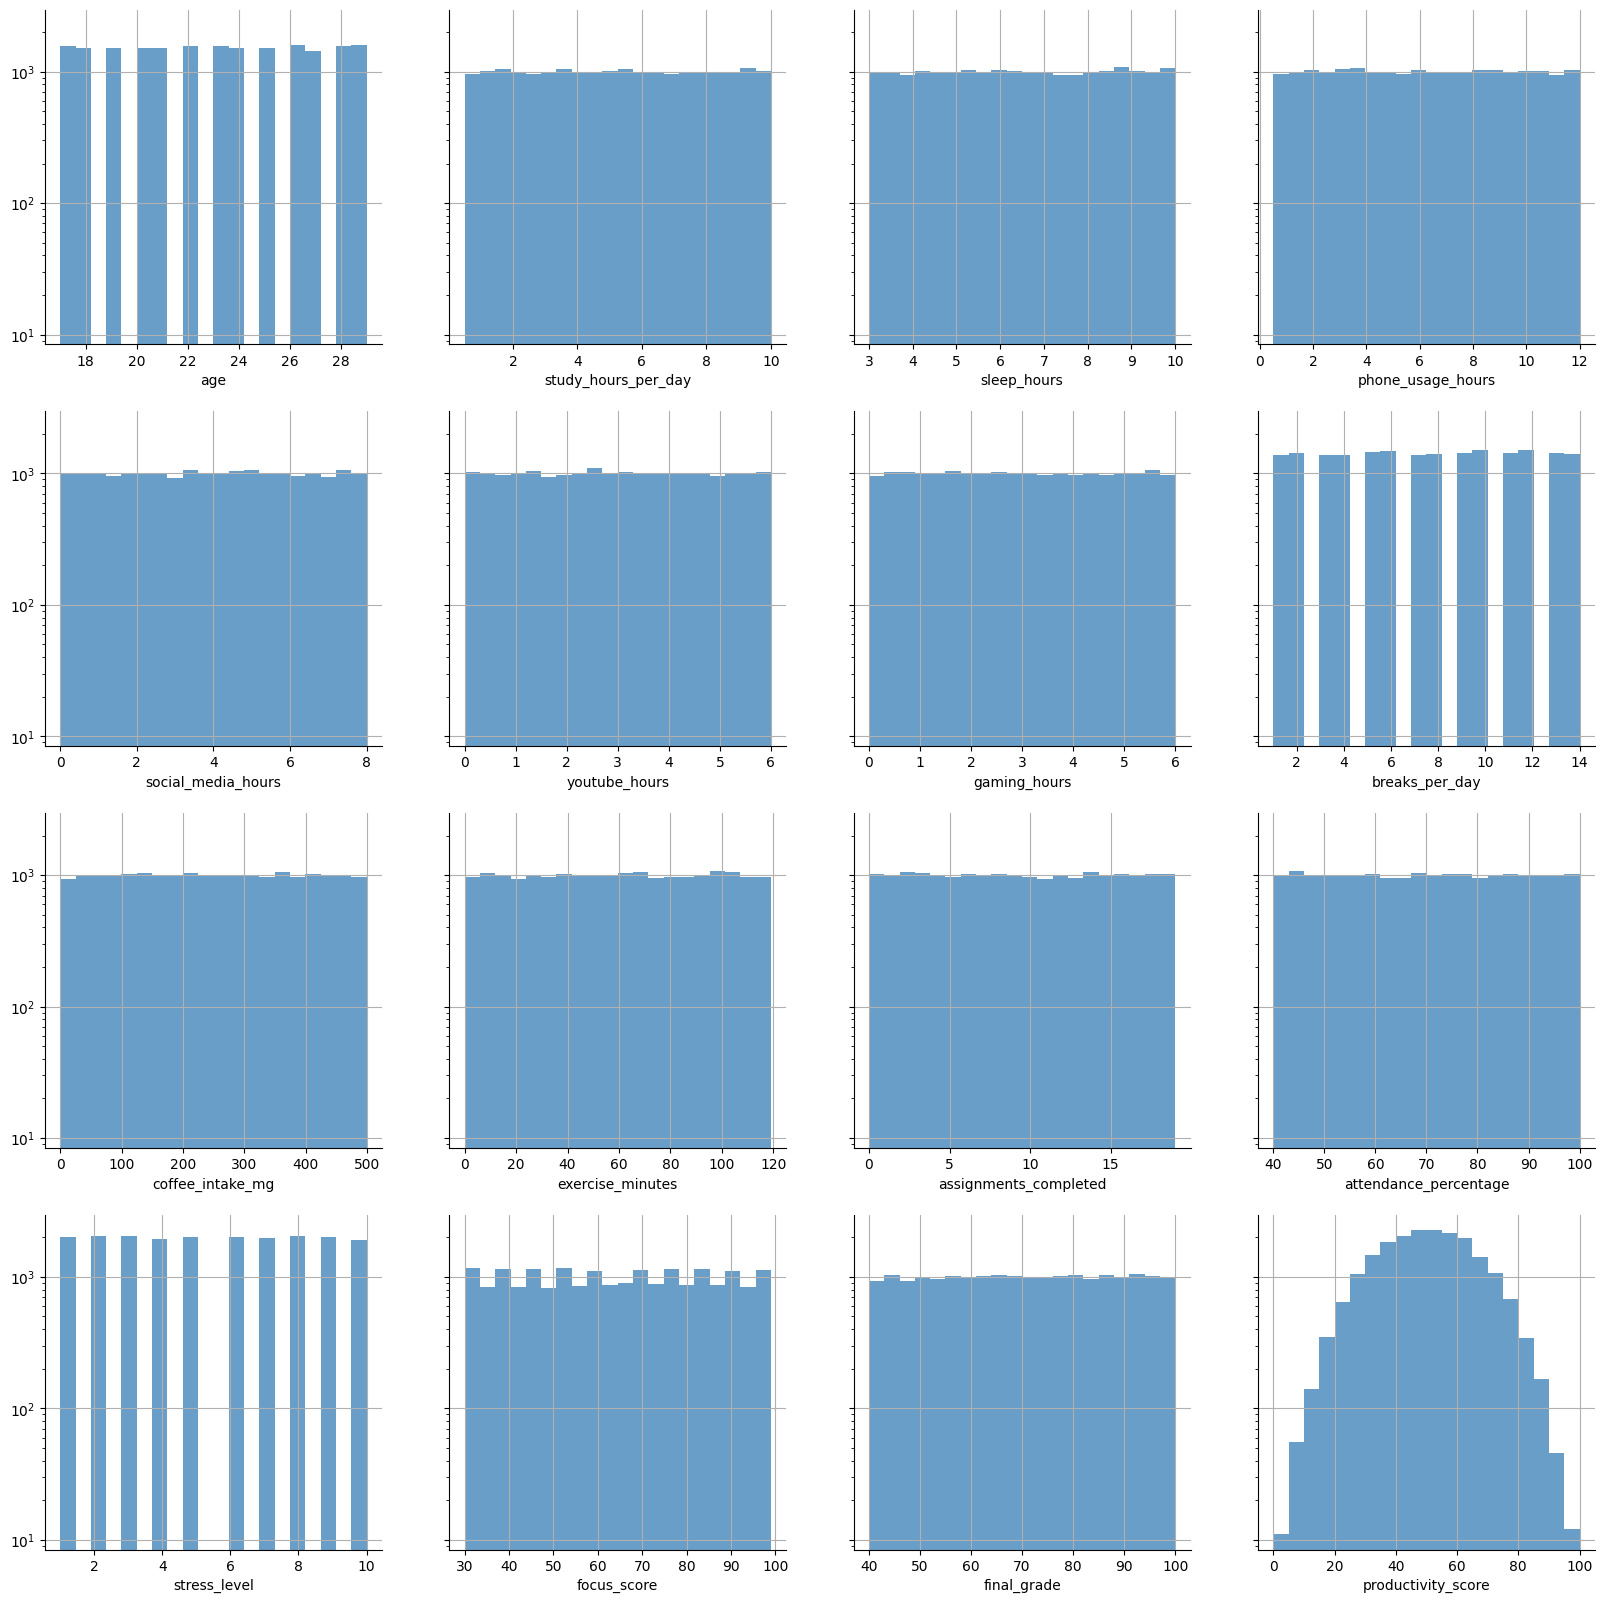

In [36]:
cols = 4
rows = int(np.ceil(len(numeric_cols) / cols))
fig, ax = plt.subplots(nrows=rows, ncols=cols, sharey=True, figsize=(20, rows * 5))
ax = ax.flatten()
hist_for_atribute_set(df, numeric_cols, ax, bin_num=20, y_scale='log')

In [19]:
def boxplot_for_atribute_set(df, labels, ax, ylim=None, ylabel=None):
  flierprops = dict(marker='o', markersize=3)

  for i, col in enumerate(labels):
    ax.boxplot(df[col], positions=[i + 1], flierprops=flierprops) # i + 1
    ax.tick_params(labelsize=10)
    ax.set_xticks(np.arange(len(labels)) + 1, labels)

    if ylim:
      ax.set_ylim(ylim)

    if ylabel:
      ax.set_ylabel(ylabel)

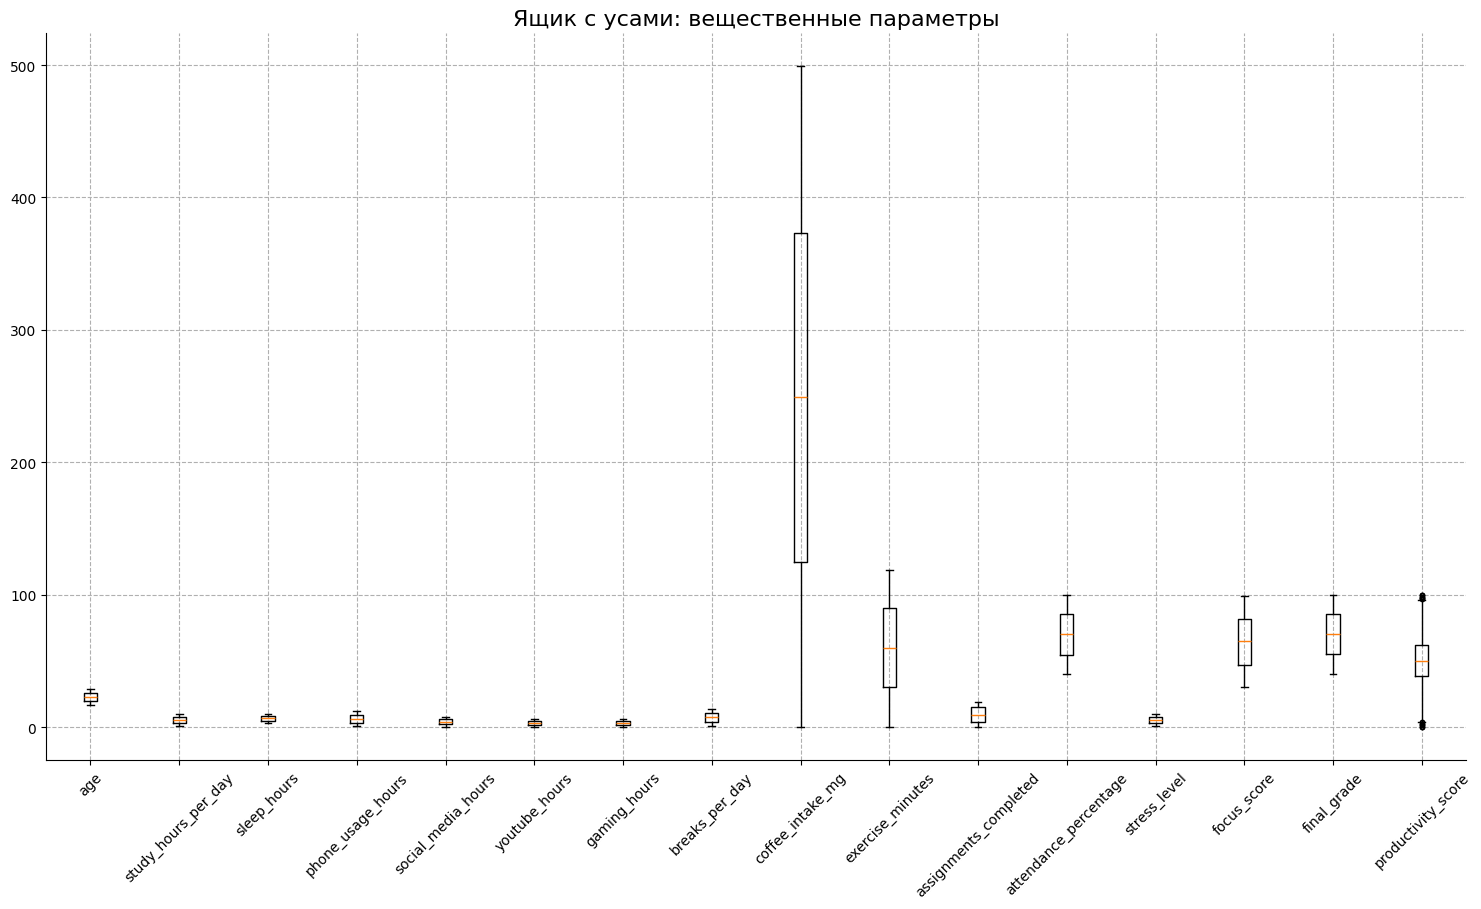

In [50]:
fig, ax = plt.subplots(figsize=(10, 10))
fig.set_figwidth(15)
plt.xticks(rotation=45)
boxplot_for_atribute_set(df, numeric_cols, ax)
ax.set_title('Ящик с усами: вещественные параметры', fontsize=16)

# уберем лишние границы графика
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# добавили немного больше координатной сетке,
# чтобы более точно определить диапазоны значений
minor_ticks = np.arange(0, 101, 5)

ax.grid(linestyle='--' )
fig.tight_layout(rect=[0, .03, 1, .95])